In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
import warnings; warnings.filterwarnings('ignore')

torch.manual_seed(0); np.random.seed(0)
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Device: {device}")

Device: cpu


In [3]:
df = pd.read_csv('/content/drive/MyDrive/GEE_exports/nc_coast_final.csv',
                 parse_dates=['timestamp'])
df = df.sort_values('timestamp').reset_index(drop=True)
print(df.shape); df[['timestamp','SST','temperature_2m']].head()

(1373, 8)


,timestamp,SST,temperature_2m
0,2020-01-01,15.752083,282.956753
1,2020-01-02,15.231250,283.567308
2,2020-01-03,14.840426,290.960683
3,2020-01-04,15.335417,292.144864
4,2020-01-05,15.462500,282.884910


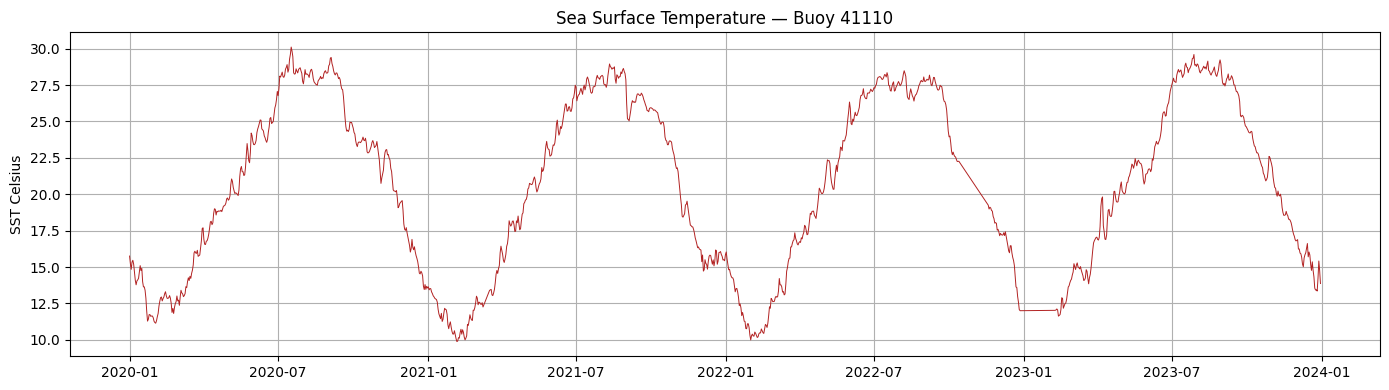

In [4]:
fig, ax = plt.subplots(figsize=(14, 4))
ax.plot(df['timestamp'], df['SST'], lw=0.7, color='firebrick')
ax.set_title('Sea Surface Temperature — Buoy 41110')
ax.set_ylabel('SST Celsius'); ax.grid(True); plt.tight_layout(); plt.show()

In [6]:
window = 30
lead_times   = [7, 30, 90]

for lag in [1, 3, 7, 14]:
    df[f'SST_lag{lag}'] = df['SST'].shift(lag)

feature_cols = ['temperature_2m', 'u_wind', 'v_wind', 'total_precipitation',
                'SST_lag1', 'SST_lag3', 'SST_lag7', 'SST_lag14']
target_col = 'SST'

In [7]:
def build_dataset(df, features, target, window, lead):
    """Build windowed dataset for a given forecast lead time."""
    needed = features + [target]
    d = df[needed].dropna().reset_index(drop=True)
    scaler_X = StandardScaler()
    scaler_y = StandardScaler()
    X_sc = scaler_X.fit_transform(d[features].values).astype(np.float32)
    y_sc = scaler_y.fit_transform(d[[target]].values).ravel().astype(np.float32)
    Xs, ys = [], []
    for i in range(window, len(X_sc) - lead):
        Xs.append(X_sc[i-window:i])
        ys.append(y_sc[i + lead])
    return np.array(Xs), np.array(ys), scaler_X, scaler_y

datasets = {}
for lead in lead_times:
    X, y, sx, sy = build_dataset(df, feature_cols, target_col, window, lead)
    datasets[lead] = {'X': X, 'y': y, 'scaler_X': sx, 'scaler_y': sy}
    print(f"Lead {lead:3d}d → X: {X.shape}  y: {y.shape}")

Lead   7d → X: (1322, 30, 8)  y: (1322,)
Lead  30d → X: (1299, 30, 8)  y: (1299,)
Lead  90d → X: (1239, 30, 8)  y: (1239,)


In [8]:
class SSTLSTM(nn.Module):
    def __init__(self, input_size, hidden=128, layers=2, dropout=0.3):
        super().__init__()
        self.lstm = nn.LSTM(input_size, hidden, num_layers=layers,
                            batch_first=True, dropout=dropout)
        self.fc = nn.Sequential(
            nn.Linear(hidden, 64), nn.ReLU(),
            nn.Dropout(dropout), nn.Linear(64, 1)
        )
    def forward(self, x):
        out, _ = self.lstm(x)
        return self.fc(out[:, -1, :]).squeeze(-1)

In [9]:
class SeqDS(Dataset):
    def __init__(self, X, y):
        self.X = torch.tensor(X); self.y = torch.tensor(y)
    def __len__(self): return len(self.X)
    def __getitem__(self, i): return self.X[i], self.y[i]

def train_model(X, y, epochs=60, batch=32, lr=1e-3):
    n = len(X)
    t, v = int(0.70*n), int(0.85*n)
    tr = DataLoader(SeqDS(X[:t], y[:t]), batch_size=batch, shuffle=True)
    va = DataLoader(SeqDS(X[t:v], y[t:v]), batch_size=batch)
    te = DataLoader(SeqDS(X[v:], y[v:]), batch_size=batch)

    model = SSTLSTM(input_size=X.shape[2]).to(device)
    opt   = torch.optim.Adam(model.parameters(), lr=lr, weight_decay=1e-4)
    sched = torch.optim.lr_scheduler.ReduceLROnPlateau(opt, patience=5, factor=0.5)
    crit  = nn.MSELoss()
    best_val, best_state, hist = float('inf'), None, {'train':[], 'val':[]}

    for ep in range(1, epochs+1):
        model.train()
        tl = []
        for xb, yb in tr:
            xb, yb = xb.to(device), yb.to(device)
            opt.zero_grad(); loss = crit(model(xb), yb); loss.backward()
            nn.utils.clip_grad_norm_(model.parameters(), 1.0); opt.step()
            tl.append(loss.item())
        model.eval()
        vl = []
        with torch.no_grad():
            for xb, yb in va: vl.append(crit(model(xb.to(device)), yb.to(device)).item())
        t_l, v_l = np.mean(tl), np.mean(vl)
        hist['train'].append(t_l); hist['val'].append(v_l)
        sched.step(v_l)
        if v_l < best_val: best_val = v_l; best_state = {k: v.cpu().clone() for k,v in model.state_dict().items()}

    model.load_state_dict(best_state)
    return model, hist, te

In [10]:
results = {}
for lead in lead_times:
    print(f"\n{'='*50}\nTraining LSTM for {lead}-day ahead SST forecast...")
    d = datasets[lead]
    model, hist, te_loader = train_model(d['X'], d['y'])

    model.eval()
    preds, trues = [], []
    with torch.no_grad():
        for xb, yb in te_loader:
            preds.extend(model(xb.to(device)).cpu().numpy())
            trues.extend(yb.numpy())

    sy = d['scaler_y']
    p = sy.inverse_transform(np.array(preds).reshape(-1,1)).ravel()
    t = sy.inverse_transform(np.array(trues).reshape(-1,1)).ravel()

    rmse = np.sqrt(mean_squared_error(t, p))
    mae  = mean_absolute_error(t, p)
    r2   = r2_score(t, p)
    print(f"Lead {lead}d → RMSE={rmse:.3f} Celsius  MAE={mae:.3f} Celsius  R^2={r2:.4f}")
    results[lead] = {'pred': p, 'true': t, 'rmse': rmse, 'mae': mae, 'r2': r2,
                     'hist': hist, 'model': model}


Training LSTM for 7-day ahead SST forecast...
Lead 7d → RMSE=1.116 Celsius  MAE=0.910 Celsius  R^2=0.9486

Training LSTM for 30-day ahead SST forecast...
Lead 30d → RMSE=2.558 Celsius  MAE=2.018 Celsius  R^2=0.7352

Training LSTM for 90-day ahead SST forecast...
Lead 90d → RMSE=3.100 Celsius  MAE=2.277 Celsius  R^2=0.6259


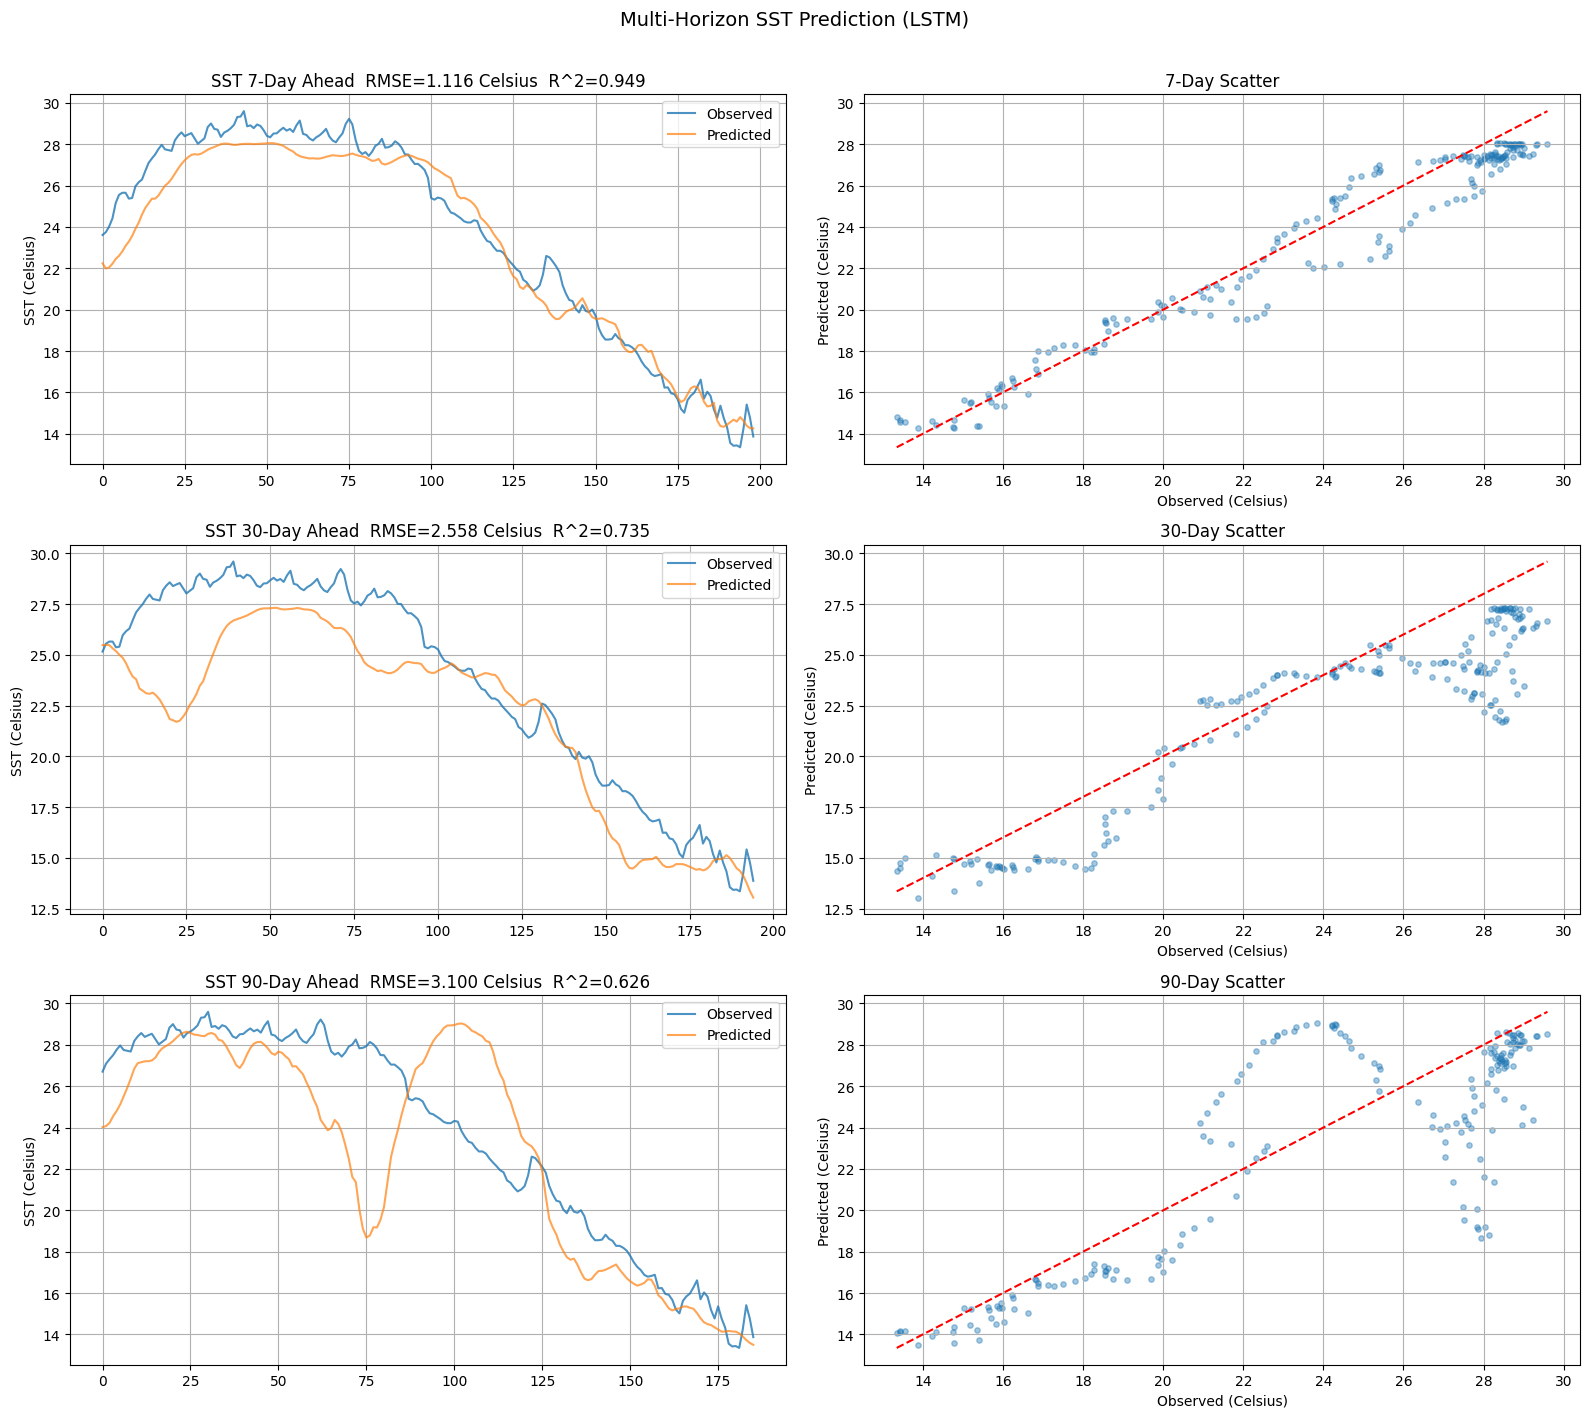

In [11]:
fig, axes = plt.subplots(3, 2, figsize=(16, 14))
for row, lead in enumerate(lead_times):
    r = results[lead]
    # Time series
    axes[row,0].plot(r['true'], label='Observed', alpha=0.8)
    axes[row,0].plot(r['pred'], label='Predicted', alpha=0.7)
    axes[row,0].set_title(f'SST {lead}-Day Ahead  RMSE={r["rmse"]:.3f} Celsius  R^2={r["r2"]:.3f}')
    axes[row,0].set_ylabel('SST (Celsius)'); axes[row,0].legend(); axes[row,0].grid(True)
    # Scatter
    mn, mx = r['true'].min(), r['true'].max()
    axes[row,1].scatter(r['true'], r['pred'], alpha=0.4, s=15)
    axes[row,1].plot([mn,mx],[mn,mx],'r--',lw=1.5)
    axes[row,1].set_xlabel('Observed (Celsius)'); axes[row,1].set_ylabel('Predicted (Celsius)')
    axes[row,1].set_title(f'{lead}-Day Scatter'); axes[row,1].grid(True)

plt.suptitle('Multi-Horizon SST Prediction (LSTM)', fontsize=14, y=1.01)
plt.tight_layout(); plt.show()

 Lead (days)  RMSE (Celsius)  MAE (Celsius)       R²
           7         1.11607       0.909743 0.948555
          30         2.55779       2.017902 0.735193
          90         3.10041       2.276909 0.625894


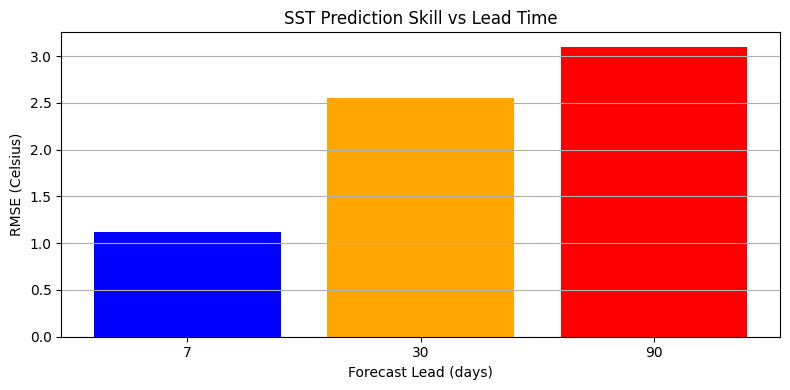

In [12]:
# Skill score summary
summary = pd.DataFrame({
    'Lead (days)': lead_times,
    'RMSE (Celsius)': [results[l]['rmse'] for l in lead_times],
    'MAE (Celsius)':  [results[l]['mae']  for l in lead_times],
    'R²':        [results[l]['r2']   for l in lead_times],
})
print(summary.to_string(index=False))

fig, ax = plt.subplots(figsize=(8,4))
ax.bar([str(l) for l in lead_times], [results[l]['rmse'] for l in lead_times],
       color=['blue','orange','red'])
ax.set_xlabel('Forecast Lead (days)'); ax.set_ylabel('RMSE (Celsius)')
ax.set_title('SST Prediction Skill vs Lead Time'); ax.grid(axis='y')
plt.tight_layout(); plt.show()

In [13]:
import os; os.makedirs('/content/drive/MyDrive/nc_coast_models', exist_ok=True)
for lead in lead_times:
    torch.save({'model_state': results[lead]['model'].state_dict(),
                'scaler_X': datasets[lead]['scaler_X'],
                'scaler_y': datasets[lead]['scaler_y'],
                'features': feature_cols, 'window': window, 'lead': lead},
               f'/content/drive/MyDrive/nc_coast_models/model3_lstm_sst_lead{lead}d.pt')
print("All SST models saved.")

All SST models saved.
